In [82]:
import os
import sys
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.validation import make_valid

sys.path.append("Camera_Level_Analysis")
from get_common_names import get_common_names


import contextily as ctx


In [115]:
# File paths and global settings
# ------------------------------------------------------------
CLEANED_PATH = "cleaned"
PREPROCESSED_PATH = "preprocessed_data"
OUTPUT_PATH = "../outputs"

# Input files
SSUSA_CSV = "ssusa_cleaned.csv"   # cleaned SSUSA observations table
IUCN_DATA = "iucn_cleaned.shp"     # cleaned IUCN range polygons
CAMERA_FOOTPRINTS = "ssusa_camera_footprints_1km.geojson"  # 1-km camera buffers
ARRAY_FOOTPRINTS = "ssusa_array_footprints_1km.geojson"  # 1-km camera buffers


# US basemap shapefile
US_SHAPE = "../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"

# Projected CRS used elsewhere when needed
AEA = "EPSG:5070"

In [13]:

# Load dataset
ssusa_file = os.path.join(CLEANED_PATH, SSUSA_CSV)
ssusa = pd.read_csv(ssusa_file, low_memory=False)

# View columns first
print(ssusa.columns)

Index(['Year', 'Project', 'Camera_Trap_Array', 'Deployment_ID', 'Sequence_ID',
       'Start_Time', 'End_Time', 'Class', 'Order', 'Family', 'Genus',
       'Species', 'Common_Name', 'Age', 'Sex', 'Group_Size', 'Site_Name',
       'Start_Date', 'End_Date', 'Survey_Nights', 'Latitude', 'Longitude',
       'Habitat', 'Development_Level', 'Feature_Type', 'Species_Name',
       'Body_Mass_g', 'Above_Threshold', 'Scope_Flag'],
      dtype='object')


In [14]:
sites = ssusa["Site_Name"].nunique()
records = len(ssusa)
species = ssusa["Species_Name"].nunique()
deployments = ssusa["Deployment_ID"].nunique()
sequences = ssusa["Sequence_ID"].nunique()

years = sorted(ssusa["Year"].dropna().unique())
n_years = len(years)

# Survey effort
total_nights = ssusa["Survey_Nights"].sum()
mean_nights = ssusa["Survey_Nights"].mean()

print("Sites:", sites)
print("Records:", records)
print("Wild mammal species:", species)
print("Years monitored:", years)
print("Number of years:", n_years)
print("Deployments:", deployments)
print("Sequences:", sequences)
print("Total survey nights:", round(total_nights,1))
print("Average nights per deployment:", round(mean_nights,1))

Sites: 6561
Records: 713319
Wild mammal species: 109
Years monitored: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Number of years: 5
Deployments: 9306
Sequences: 692654
Total survey nights: 32977461
Average nights per deployment: 46.2


In [15]:
ssusa["Start_Date"] = pd.to_datetime(ssusa["Start_Date"], errors="coerce")

# Extract year + numeric month
ssusa["Year"] = ssusa["Start_Date"].dt.year
ssusa["Month_Num"] = ssusa["Start_Date"].dt.month
ssusa["Month"] = ssusa["Start_Date"].dt.month_name()

# Sort months correctly for each year
months_per_year = (
    ssusa[["Year", "Month_Num", "Month"]]
    .drop_duplicates()
    .sort_values(["Year", "Month_Num"])
    .groupby("Year")["Month"]
    .apply(list)
)

print(months_per_year)

Year
2019    [August, September, October, November]
2020              [August, September, October]
2021    [August, September, October, November]
2022    [August, September, October, November]
2023    [August, September, October, November]
Name: Month, dtype: object


In [16]:
pd.to_datetime(df["Start_Date"], errors="coerce").dt.year.value_counts().sort_index()

Start_Date
2019     92649
2020    108635
2021    120890
2022    176674
2023    214471
Name: count, dtype: int64

In [32]:
# Load IUCN shapefile
iucn_file = os.path.join(CLEANED_PATH, IUCN_DATA)
iucn = gpd.read_file(iucn_file)

# View columns first
print(iucn.columns)
print(iucn.head())

Index(['id_no', 'sci_name', 'presence', 'origin', 'seasonal', 'category',
       'compiler', 'yrcompiled', 'citation', 'subspecies', 'subpop', 'source',
       'island', 'tax_comm', 'dist_comm', 'generalisd', 'legend', 'class',
       'order', 'family', 'genus', 'marine', 'terrestria', 'freshwater',
       'body_mass', 'ab_thres', 'scope_flag', 'geometry'],
      dtype='object')
   id_no                  sci_name  presence  origin  seasonal category  \
0    699            cuniculus paca         1       3         1       LC   
1    699            cuniculus paca         1       1         1       LC   
2    914            alouatta pigra         1       1         1       EN   
3   1149  ammospermophilus nelsoni         1       1         1       EN   
4   1677     antilocapra americana         1       1         1       LC   

                                 compiler  yrcompiled  \
0  IUCN SSC Small Mammal Specialist Group        2016   
1  IUCN SSC Small Mammal Specialist Group        2016

In [18]:
print("Total terrestrial mammal species:", iucn["sci_name"].nunique())
print("Total range polygons:", len(iucn))
print("Orders:", iucn["order"].nunique())
print("Families:", iucn["family"].nunique())

Total terrestrial mammal species: 575
Total range polygons: 733
Orders: 10
Families: 38


### Star Figure

In [22]:
cams = gpd.read_file(os.path.join(PREPROCESSED_PATH, CAMERA_FOOTPRINTS))
world = gpd.read_file(US_SHAPE)

In [23]:
# Keep only United States from the world shapefile
us = world[world["ADMIN"] == "United States of America"].copy()

In [24]:

print("\nCamera footprint columns:", cams.columns)
print("Camera footprint CRS:", cams.crs)
print("\nUS basemap columns:", us.columns)
print("US basemap CRS:", us.crs)


Camera footprint columns: Index(['Longitude', 'Latitude', 'camera_fp_id', 'geometry'], dtype='object')
Camera footprint CRS: EPSG:5070

US basemap columns: Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)
US basemap CRS: EPSG:4326


In [33]:
# convert all spatial layers to the same projected CRS

iucn = iucn.to_crs(AEA)
cams = cams.to_crs(AEA)
us = us.to_crs(AEA)

### Create camera_fp_id in SSUSA and find presence

In [27]:
# create camera_fp_id in SSUSA using Longitude and Latitude,
# then find which footprints have the selected species present

def make_camera_id(lon, lat):
    return f"{lon:.8f}_{lat:.8f}"

# Ensure numeric coordinates
ssusa["Longitude"] = pd.to_numeric(ssusa["Longitude"], errors="coerce")
ssusa["Latitude"] = pd.to_numeric(ssusa["Latitude"], errors="coerce")

# Create footprint ID in SSUSA table
ssusa["camera_fp_id"] = ssusa.apply(
    lambda row: make_camera_id(row["Longitude"], row["Latitude"]),
    axis=1
)

# Use this as the common site / footprint key
site_col = "camera_fp_id"

# Quick check
print(ssusa[[site_col, "Longitude", "Latitude"]].head())

                camera_fp_id  Longitude  Latitude
0  -136.22250000_59.42643000  -136.2225  59.42643
1  -136.22250000_59.42643000  -136.2225  59.42643
2  -136.22250000_59.42643000  -136.2225  59.42643
3  -136.22250000_59.42643000  -136.2225  59.42643
4  -136.22250000_59.42643000  -136.2225  59.42643


### Dissolve IUCN polygons by species

In [34]:
print("Invalid geometries before fix:", (~iucn.is_valid).sum())

iucn["geometry"] = iucn.geometry.apply(make_valid)

print("Invalid geometries after fix:", (~iucn.is_valid).sum())

iucn_species = (
    iucn[["sci_name", "geometry"]]
    .dissolve(by="sci_name")
    .reset_index()
)

print(iucn_species.head())
print("Total species ranges:", len(iucn_species))

Invalid geometries before fix: 4


/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)
/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)
/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)
/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)


Invalid geometries after fix: 0


/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


                     sci_name  \
0                 alces alces   
1      alexandromys oeconomus   
2              alouatta pigra   
3   ammospermophilus harrisii   
4  ammospermophilus interpres   

                                            geometry  
0  MULTIPOLYGON (((-2335436.156 4113405.681, -233...  
1  MULTIPOLYGON (((-4292991.707 5075273.204, -429...  
2  MULTIPOLYGON (((488536.564 -495898.459, 488537...  
3  POLYGON ((-1513229.736 708434.697, -1513344.68...  
4  POLYGON ((-826619 834561.903, -838992.171 8651...  
Total species ranges: 575


In [35]:
iucn_species = (
    iucn[["sci_name", "geometry"]]
    .dissolve(by="sci_name")
    .reset_index()
)

print(iucn_species.head())
print("Total species ranges:", len(iucn_species))

/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


                     sci_name  \
0                 alces alces   
1      alexandromys oeconomus   
2              alouatta pigra   
3   ammospermophilus harrisii   
4  ammospermophilus interpres   

                                            geometry  
0  MULTIPOLYGON (((-2335436.156 4113405.681, -233...  
1  MULTIPOLYGON (((-4292991.707 5075273.204, -429...  
2  MULTIPOLYGON (((488536.564 -495898.459, 488537...  
3  POLYGON ((-1513229.736 708434.697, -1513344.68...  
4  POLYGON ((-826619 834561.903, -838992.171 8651...  
Total species ranges: 575


### Spatial Join with Camera Footprints 

In [36]:
join = gpd.sjoin(
    cams[[site_col, "geometry"]],
    iucn_species,
    how="inner",
    predicate="intersects"
)

print(join.head())
print("Total intersecting footprint-range matches:", len(join))

                camera_fp_id  \
0  -136.22250000_59.42643000   
0  -136.22250000_59.42643000   
0  -136.22250000_59.42643000   
0  -136.22250000_59.42643000   
0  -136.22250000_59.42643000   

                                            geometry  index_right  \
0  POLYGON ((-2435854.994 4519384.214, -2435859.8...          274   
0  POLYGON ((-2435854.994 4519384.214, -2435859.8...          344   
0  POLYGON ((-2435854.994 4519384.214, -2435859.8...          492   
0  POLYGON ((-2435854.994 4519384.214, -2435859.8...          350   
0  POLYGON ((-2435854.994 4519384.214, -2435859.8...          226   

               sci_name  
0         myotis volans  
0   odocoileus hemionus  
0       sorex monticola  
0   oreamnos americanus  
0  microtus longicaudus  
Total intersecting footprint-range matches: 321728


### Count camera footprints in each species range

In [37]:
range_counts = (
    join.groupby("sci_name")[site_col]
    .nunique()  # count unique footprints per species
    .reset_index(name="n_footprints")
    .sort_values("n_footprints", ascending=False)
)

print(range_counts.head(10))

                      sci_name  n_footprints
63            eptesicus fuscus          7137
20               canis latrans          7101
107          mephitis mephitis          7077
144            neogale frenata          7026
84           lasiurus cinereus          6975
219              procyon lotor          6935
181     odocoileus virginianus          6590
81   lasionycteris noctivagans          6370
297              vulpes vulpes          6362
292   urocyon cinereoargenteus          6203


In [41]:
# Top 10 species
top10 = range_counts.head(10).copy()

# Get common names
name_map = get_common_names(top10["sci_name"].tolist())

# Add common names
top10["common_name"] = top10["sci_name"].map(name_map)

# Reorder columns
top10 = top10[["sci_name", "common_name", "n_footprints"]]

print(top10)

                      sci_name         common_name  n_footprints
63            eptesicus fuscus       Big Brown Bat          7137
20               canis latrans              Coyote          7101
107          mephitis mephitis       Striped Skunk          7077
144            neogale frenata  Long-tailed Weasel          7026
84           lasiurus cinereus           Hoary Bat          6975
219              procyon lotor             Raccoon          6935
181     odocoileus virginianus   White-tailed Deer          6590
81   lasionycteris noctivagans   Silver-haired Bat          6370
297              vulpes vulpes          Silver Fox          6362
292   urocyon cinereoargenteus   Northern Gray Fox          6203


### Using procyon lotor (Raccoon) for plotting for Star image 

In [43]:
plot_species = "procyon lotor"

plot_range = iucn_species[iucn_species["sci_name"] == plot_species].copy()

print(plot_range[["sci_name"]])
print("Number of range features:", len(plot_range))

          sci_name
424  procyon lotor
Number of range features: 1


In [44]:
# get all camera footprints that intersect the Procyon lotor range

plot_join = gpd.sjoin(
    cams[[site_col, "geometry"]],
    plot_range,
    how="inner",
    predicate="intersects"
).drop(columns=["index_right"])

plot_footprints = plot_join.drop_duplicates(subset=[site_col]).copy()

print("Number of intersecting camera footprints:", len(plot_footprints))
print(plot_footprints.head())

Number of intersecting camera footprints: 6935
                camera_fp_id  \
8   -85.48810000_32.66049000   
9   -85.48588000_32.66487000   
10  -85.48485000_32.66440000   
11  -85.48567000_32.66379000   
12  -85.48630000_32.66455000   

                                             geometry       sci_name  
8   POLYGON ((979422.135 1119582.261, 979417.32 11...  procyon lotor  
9   POLYGON ((979573.981 1120090.692, 979569.166 1...  procyon lotor  
10  POLYGON ((979675.243 1120049.194, 979670.428 1...  procyon lotor  
11  POLYGON ((979606.748 1119973.124, 979601.933 1...  procyon lotor  
12  POLYGON ((979538.991 1120050.891, 979534.176 1...  procyon lotor  


In [45]:
# label footprints by whether Procyon lotor was observed there in SSUSA

plot_footprints[site_col] = plot_footprints[site_col].astype(str)

present_sites = set(
    ssusa.loc[ssusa["Species_Name"] == plot_species, "camera_fp_id"]
    .dropna()
    .astype(str)
    .unique()
)

plot_footprints["presence_status"] = plot_footprints[site_col].apply(
    lambda x: "Present" if x in present_sites else "Not detected"
)

print(plot_footprints["presence_status"].value_counts())

presence_status
Present         3610
Not detected    3325
Name: count, dtype: int64


In [65]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


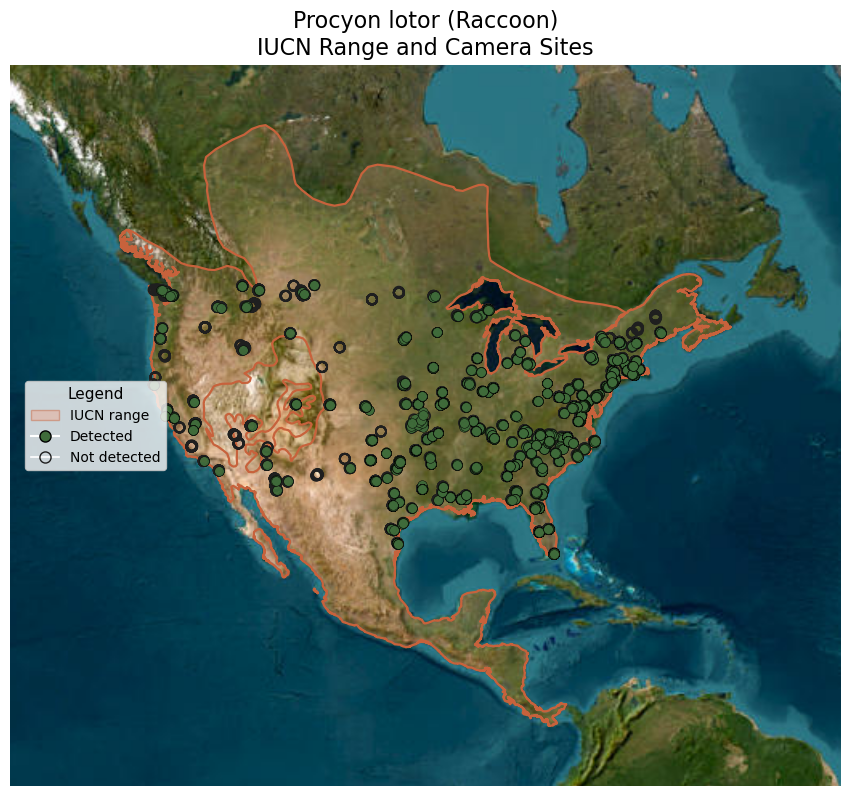

In [90]:
# -----------------------------------
# Species
# -----------------------------------
plot_species = "procyon lotor"

plot_range = iucn[iucn["sci_name"] == plot_species].copy()
plot_range = plot_range[plot_range.geometry.notnull()]
plot_range = plot_range[~plot_range.geometry.is_empty]

plot_points = plot_footprints.copy()
plot_points["geometry"] = plot_points.geometry.centroid

# Reproject
plot_range_web = plot_range.to_crs(epsg=3857)
plot_points_web = plot_points.to_crs(epsg=3857)

# -----------------------------------
# Colors
# -----------------------------------
detected_color = "#3F6B3A"  # green
not_detected_edge = "#1F1F1F"
range_fill = "#F0A78D"   # transparent  fill
range_edge = "#C7623C"


# -----------------------------------
# Title formatting
# -----------------------------------
title_species = "Procyon lotor (Raccoon)"

# -----------------------------------
# Figure
# -----------------------------------
fig, ax = plt.subplots(figsize=(11.1, 8.1))

# -----------------------------------
# Bounds
# -----------------------------------
minx, miny, maxx, maxy = plot_range_web.total_bounds

if np.isfinite([minx, miny, maxx, maxy]).all():
    pad_x = (maxx - minx) * 0.18
    pad_y = (maxy - miny) * 0.10
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

# -----------------------------------
# Satellite basemap like reference
# -----------------------------------
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

# -----------------------------------
# Transparent IUCN range
# -----------------------------------
plot_range_web.plot(
    ax=ax,
    facecolor=range_fill,
    edgecolor="none",
    alpha=0.20,
    zorder=2
)

plot_range_web.boundary.plot(
    ax=ax,
    color=range_edge,
    linewidth=1.6,
    zorder=3
)

# -----------------------------------
# Not detected = blank circles
# -----------------------------------
plot_points_web[
    plot_points_web["presence_status"] == "Not detected"
].plot(
    ax=ax,
    marker="o",
    markersize=52,
    facecolor="none",
    edgecolor=not_detected_edge,
    linewidth=1.3,
    zorder=4
)

# -----------------------------------
# Detected = filled green
# -----------------------------------
plot_points_web[
    plot_points_web["presence_status"] == "Present"
].plot(
    ax=ax,
    marker="o",
    markersize=48,
    color=detected_color,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.95,
    zorder=5
)

# -----------------------------------
# Title
# -----------------------------------
ax.set_title(
    f"{title_species}\nIUCN Range and Camera Sites",
    fontsize=16,
    pad=8
)

# -----------------------------------
# Legend
# -----------------------------------
legend_elements = [
    Patch(facecolor=range_fill, edgecolor=range_edge, alpha=0.45, label="IUCN range"),
    Line2D([0], [0], marker='o', color='w', label='Detected',
           markerfacecolor=detected_color, markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Not detected',
           markerfacecolor='none', markeredgecolor=not_detected_edge,
           markersize=8, linewidth=1.2),
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(0.01, 0.50),
    frameon=True,
    fontsize=10,
    title="Legend",
    title_fontsize=11
)

# -----------------------------------
# Final layout
# -----------------------------------
ax.set_axis_off()

plt.subplots_adjust(left=0.03, right=0.985, top=0.92, bottom=0.03)
plt.show()

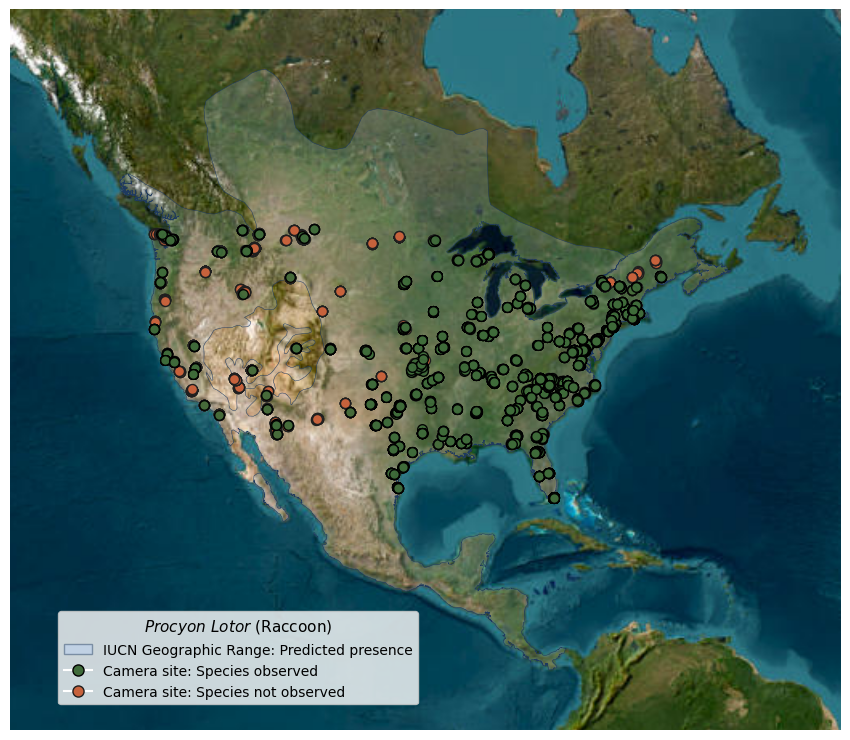

In [113]:

# -----------------------------------
# Species
# -----------------------------------
plot_species = "procyon lotor"

plot_range = iucn[iucn["sci_name"] == plot_species].copy()
plot_range = plot_range[plot_range.geometry.notnull()]
plot_range = plot_range[~plot_range.geometry.is_empty]

plot_points = plot_footprints.copy()
plot_points["geometry"] = plot_points.geometry.centroid

# Reproject
plot_range_web = plot_range.to_crs(epsg=3857)
plot_points_web = plot_points.to_crs(epsg=3857)

# -----------------------------------
# Colors
# -----------------------------------
detected_color = "#3F6B3A"  # green
not_detected_edge = "#1F1F1F"
not_detected_color = "#C7623C"
range_fill = "#B4CEF3"   # transparent  fill
range_edge = "#1F3A5F"


# -----------------------------------
# Title formatting
# -----------------------------------
title_species = "Procyon lotor (Raccoon)"

# -----------------------------------
# Figure
# -----------------------------------
fig, ax = plt.subplots(figsize=(11.1, 8.1))

# -----------------------------------
# Bounds
# -----------------------------------
minx, miny, maxx, maxy = plot_range_web.total_bounds

if np.isfinite([minx, miny, maxx, maxy]).all():
    pad_x = (maxx - minx) * 0.18
    pad_y = (maxy - miny) * 0.10
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

# -----------------------------------
# Satellite basemap like reference
# -----------------------------------
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

# -----------------------------------
# Transparent IUCN range
# -----------------------------------
plot_range_web.plot(
    ax=ax,
    facecolor=range_fill,
    edgecolor="none",
    alpha=0.20,
    zorder=2
)

plot_range_web.boundary.plot(
    ax=ax,
    color=range_edge,
    linewidth=0.35,
    zorder=3
)

# -----------------------------------
# Not detected = blank circles
# -----------------------------------
plot_points_web[
    plot_points_web["presence_status"] == "Not detected"
].plot(
    ax=ax,
    marker="o",
    markersize=52,
    facecolor=not_detected_color,
    edgecolor=not_detected_edge,
    linewidth=1.0,
    zorder=4
)

# -----------------------------------
# Detected = filled green
# -----------------------------------
plot_points_web[
    plot_points_web["presence_status"] == "Present"
].plot(
    ax=ax,
    marker="o",
    markersize=48,
    color=detected_color,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.95,
    zorder=5
)

# -----------------------------------
# Title
# -----------------------------------
'''ax.set_title(
    f"{title_species}\nIUCN Range and Camera Sites",
    fontsize=16,
    pad=8
)'''

# -----------------------------------
# Legend
# -----------------------------------
legend_elements = [
    Patch(facecolor=range_fill, edgecolor=range_edge, alpha=0.45,
          label="IUCN Geographic Range: Predicted presence"),
    
    Line2D([0], [0], marker='o', color='w',
           label='Camera site: Species observed',
           markerfacecolor=detected_color,
           markeredgecolor='black', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='Camera site: Species not observed',
           markerfacecolor=not_detected_color,
           markeredgecolor=not_detected_edge, markersize=8)
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(0.05, 0.10),
    frameon=True,
    fontsize=10,
    title=r"$\it{Procyon\ Lotor}$ (Raccoon)",
    title_fontsize=11
)

# -----------------------------------
# Final layout
# -----------------------------------
ax.set_axis_off()

plt.subplots_adjust(left=0.03, right=0.985, top=0.92, bottom=0.03)
plt.show()

## Compare Jaccard Similarity for Camera Level and Array Level

In [117]:
# ------------------------------------------------------------
# Load array footprints
# ------------------------------------------------------------
# Set array ID column
array_col = "Camera_Trap_Array"

arrays = gpd.read_file(os.path.join(PREPROCESSED_PATH, ARRAY_FOOTPRINTS))

# Reproject to same CRS
arrays = arrays.to_crs(AEA)


print("Rows:", len(arrays))
print("CRS:", arrays.crs)
print(arrays.columns.tolist())

Rows: 262
CRS: EPSG:5070
['Camera_Trap_Array', 'geometry']


In [119]:
## SSUSA has camera_fp_id, so we can use that to link to the array footprints
print("Check columns in SSUSA for linking to array footprints: ")
print(ssusa.columns.tolist())


Check columns in SSUSA for linking to array footprints: 
['Year', 'Project', 'Camera_Trap_Array', 'Deployment_ID', 'Sequence_ID', 'Start_Time', 'End_Time', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Common_Name', 'Age', 'Sex', 'Group_Size', 'Site_Name', 'Start_Date', 'End_Date', 'Survey_Nights', 'Latitude', 'Longitude', 'Habitat', 'Development_Level', 'Feature_Type', 'Species_Name', 'Body_Mass_g', 'Above_Threshold', 'Scope_Flag', 'Month_Num', 'Month', 'camera_fp_id']


In [120]:
print("Unique IUCN species:", len(iucn_species))
iucn_species.head()

Unique IUCN species: 575


,sci_name,geometry
0,alces alces,"MULTIPOLYGON (((-2335436.156 4113405.681, -233..."
1,alexandromys oeconomus,"MULTIPOLYGON (((-4292991.707 5075273.204, -429..."
2,alouatta pigra,"MULTIPOLYGON (((488536.564 -495898.459, 488537..."
3,ammospermophilus harrisii,"POLYGON ((-1513229.736 708434.697, -1513344.68..."
4,ammospermophilus interpres,"POLYGON ((-826619 834561.903, -838992.171 8651..."


### Camera Level - Observed and Predicted Counts

 groups the SSUSA detections by `camera_fp_id` and converts the species observations at each camera into a Python `set`.

Using a set is important because Jaccard similarity compares **unique species present**,

In [121]:
#  Predict species for each camera footprint using IUCN overlap

camera_join = gpd.sjoin(
    cams[["camera_fp_id", "geometry"]],
    iucn_species,
    how="inner",
    predicate="intersects"
)[["camera_fp_id", "sci_name"]].drop_duplicates()

camera_pred = (
    camera_join.groupby("camera_fp_id")["sci_name"]
    .apply(set)
    .reset_index(name="predicted_species")
)

print("Camera footprints with predictions:", len(camera_pred))
camera_pred.head()

Camera footprints with predictions: 7327


,camera_fp_id,predicted_species
0,-100.23311000_35.92725000,"{myotis velifer, peromyscus leucopus, taxidea ..."
1,-100.24179000_35.92768000,"{myotis velifer, peromyscus leucopus, taxidea ..."
2,-100.24180200_35.92767900,"{myotis velifer, peromyscus leucopus, taxidea ..."
3,-100.24181000_35.92775000,"{myotis velifer, peromyscus leucopus, taxidea ..."
4,-100.24212710_35.92756100,"{myotis velifer, peromyscus leucopus, taxidea ..."


In [123]:
# Build observed species sets for each camera footprint
camera_obs = (
    ssusa.groupby("camera_fp_id")["Species_Name"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .reset_index(name="observed_species")
)

print("Camera footprints with observed species:", len(camera_obs))
camera_obs.head()

Camera footprints with observed species: 7340


,camera_fp_id,observed_species
0,-100.23311000_35.92725000,"{odocoileus virginianus, procyon lotor}"
1,-100.24179000_35.92768000,"{odocoileus virginianus, procyon lotor}"
2,-100.24180200_35.92767900,"{canis latrans, odocoileus hemionus, procyon l..."
3,-100.24181000_35.92775000,{odocoileus virginianus}
4,-100.24212710_35.92756100,{odocoileus virginianus}


### Array Level Observed and Predicted counts

In [124]:
array_join = gpd.sjoin(
    arrays[[array_col, "geometry"]],
    iucn_species,
    how="inner",
    predicate="intersects"
)[[array_col, "sci_name"]].drop_duplicates()

array_pred = (
    array_join.groupby(array_col)["sci_name"]
    .apply(set)
    .reset_index(name="predicted_species")
)

print("Arrays with predicted species:", len(array_pred))
array_pred.head()

Arrays with predicted species: 261


,Camera_Trap_Array,predicted_species
0,ARNWR,"{peromyscus leucopus, myotis septentrionalis, ..."
1,AandM,"{taxidea taxus, peromyscus leucopus, spilogale..."
2,Abilene,"{neotoma leucodon, myotis velifer, peromyscus ..."
3,AbitaFlats,"{peromyscus leucopus, spilogale putorius, dasy..."
4,Afognak,"{ursus arctos, alexandromys oeconomus, myotis ..."


In [125]:
# Build observed species sets for each camera trap array
array_obs = (
    ssusa.groupby(array_col)["Species_Name"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .reset_index(name="observed_species")
)

print("Arrays with observed species:", len(array_obs))
array_obs.head()

Arrays with observed species: 262


,Camera_Trap_Array,observed_species
0,ARNWR,"{procyon lotor, ursus americanus, lynx rufus, ..."
1,AandM,"{pecari tajacu, procyon lotor, dasypus novemci..."
2,Abilene,"{urocyon cinereoargenteus, procyon lotor, eret..."
3,AbitaFlats,"{procyon lotor, dasypus novemcinctus, sus scro..."
4,Afognak,"{ursus arctos, martes americana, cervus elaphu..."


### Jaccard similarity function

In [126]:
# Formula:
# J(A, B) = |A ∩ B| / |A ∪ B|

def jaccard_similarity(obs, pred):
    # Replace missing values with empty sets
    obs = obs if isinstance(obs, set) else set()
    pred = pred if isinstance(pred, set) else set()

    # Compute intersection and union
    intersection = obs & pred
    union = obs | pred

    # Jaccard is undefined if both sets are empty
    if len(union) == 0:
        return np.nan

    return len(intersection) / len(union)

In [127]:
# Calculate camera-level Jaccard similarity

camera_compare = pd.merge(
    camera_obs,
    camera_pred,
    on="camera_fp_id",
    how="outer"
)

# Replace missing values with empty sets
camera_compare["observed_species"] = camera_compare["observed_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

camera_compare["predicted_species"] = camera_compare["predicted_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

# Shared species
camera_compare["common_species"] = camera_compare.apply(
    lambda row: row["observed_species"] & row["predicted_species"],
    axis=1
)

# Jaccard similarity
camera_compare["jaccard"] = camera_compare.apply(
    lambda row: jaccard_similarity(
        row["observed_species"],
        row["predicted_species"]
    ),
    axis=1
)

# Label for plotting later
camera_compare["level"] = "Camera"

print("Camera footprints compared:", len(camera_compare))
print("Median Jaccard:", camera_compare["jaccard"].median())

camera_compare.head()

Camera footprints compared: 7340
Median Jaccard: 0.08403954802259886


,camera_fp_id,observed_species,predicted_species,common_species,jaccard,level
0,-100.23311000_35.92725000,"{odocoileus virginianus, procyon lotor}","{myotis velifer, peromyscus leucopus, taxidea ...","{odocoileus virginianus, procyon lotor}",0.046512,Camera
1,-100.24179000_35.92768000,"{odocoileus virginianus, procyon lotor}","{myotis velifer, peromyscus leucopus, taxidea ...","{odocoileus virginianus, procyon lotor}",0.046512,Camera
2,-100.24180200_35.92767900,"{canis latrans, odocoileus hemionus, procyon l...","{myotis velifer, peromyscus leucopus, taxidea ...","{canis latrans, odocoileus hemionus, procyon l...",0.093023,Camera
3,-100.24181000_35.92775000,{odocoileus virginianus},"{myotis velifer, peromyscus leucopus, taxidea ...",{odocoileus virginianus},0.023256,Camera
4,-100.24212710_35.92756100,{odocoileus virginianus},"{myotis velifer, peromyscus leucopus, taxidea ...",{odocoileus virginianus},0.023256,Camera


In [128]:
# Calculate array-level Jaccard similarity
array_compare = pd.merge(
    array_obs,
    array_pred,
    on=array_col,
    how="outer"
)

# Replace missing values with empty sets
array_compare["observed_species"] = array_compare["observed_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

array_compare["predicted_species"] = array_compare["predicted_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

# Shared species
array_compare["common_species"] = array_compare.apply(
    lambda row: row["observed_species"] & row["predicted_species"],
    axis=1
)

# Jaccard similarity
array_compare["jaccard"] = array_compare.apply(
    lambda row: jaccard_similarity(
        row["observed_species"],
        row["predicted_species"]
    ),
    axis=1
)

# Label for plotting later
array_compare["level"] = "Array"

print("Arrays compared:", len(array_compare))
print("Median Jaccard:", array_compare["jaccard"].median())

array_compare.head()

Arrays compared: 262
Median Jaccard: 0.2222222222222222


,Camera_Trap_Array,observed_species,predicted_species,common_species,jaccard,level
0,ARNWR,"{procyon lotor, ursus americanus, lynx rufus, ...","{peromyscus leucopus, myotis septentrionalis, ...","{procyon lotor, ursus americanus, lynx rufus, ...",0.250000,Array
1,AandM,"{pecari tajacu, procyon lotor, dasypus novemci...","{taxidea taxus, peromyscus leucopus, spilogale...","{pecari tajacu, procyon lotor, dasypus novemci...",0.204545,Array
2,Abilene,"{urocyon cinereoargenteus, procyon lotor, eret...","{neotoma leucodon, myotis velifer, peromyscus ...","{urocyon cinereoargenteus, procyon lotor, eret...",0.272727,Array
3,AbitaFlats,"{procyon lotor, dasypus novemcinctus, sus scro...","{peromyscus leucopus, spilogale putorius, dasy...","{procyon lotor, dasypus novemcinctus, lynx ruf...",0.150000,Array
4,Afognak,"{ursus arctos, martes americana, cervus elaphu...","{ursus arctos, alexandromys oeconomus, myotis ...",{ursus arctos},0.111111,Array


In [129]:
plot_df = pd.concat(
    [
        camera_compare[["level", "jaccard"]],
        array_compare[["level", "jaccard"]],
    ],
    ignore_index=True
).dropna()

print("Rows in plotting table:", len(plot_df))
print("\nSummary by level:")
print(plot_df.groupby("level")["jaccard"].describe())

plot_df.head()

Rows in plotting table: 7602

Summary by level:
         count      mean       std  min       25%       50%       75%  \
level                                                                   
Array    262.0  0.223265  0.077273  0.0  0.183808  0.222222  0.269776   
Camera  7340.0  0.089961  0.054622  0.0  0.046512  0.084040  0.127660   

             max  
level             
Array   0.459459  
Camera  0.351351  


,level,jaccard
0,Camera,0.046512
1,Camera,0.046512
2,Camera,0.093023
3,Camera,0.023256
4,Camera,0.023256


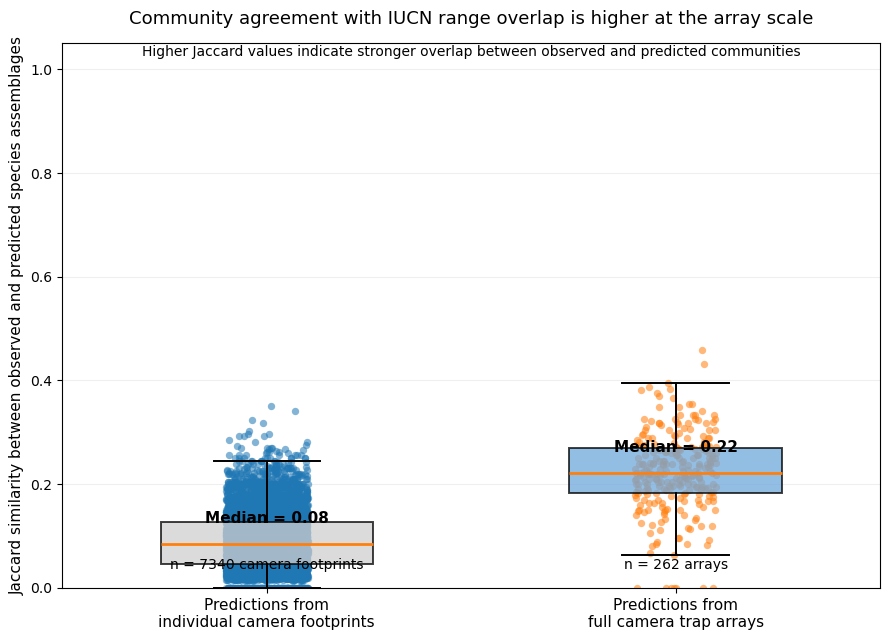

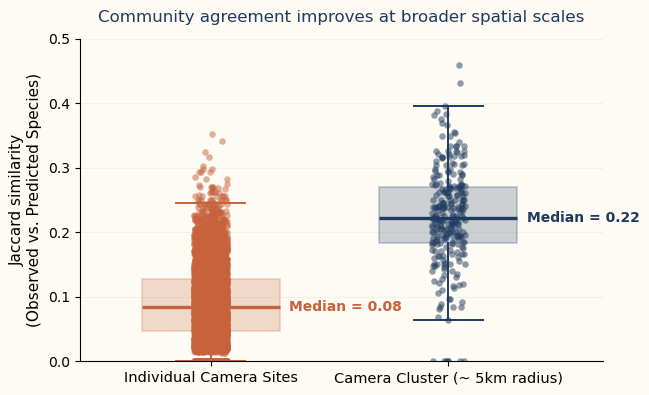

In [144]:
# Pull values
camera_vals = plot_df.loc[plot_df["level"] == "Camera", "jaccard"].dropna().values
array_vals  = plot_df.loc[plot_df["level"] == "Array", "jaccard"].dropna().values

camera_median = np.median(camera_vals)
array_median  = np.median(array_vals)

# Colors
bg_color = "#FDFBF3"
camera_color = "#C7623C"
array_color  = "#1F3A5F"

# Exact requested size
fig, ax = plt.subplots(figsize=(6.38, 4.89), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Wider boxes help reduce tall/narrow appearance
bp = ax.boxplot(
    [camera_vals, array_vals],
    positions=[1, 2],
    widths=0.58,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2.4),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    boxprops=dict(linewidth=1.4)
)

# Color styling
for patch, c in zip(bp["boxes"], [camera_color, array_color]):
    patch.set_facecolor(c)
    patch.set_alpha(0.22)
    patch.set_edgecolor(c)

for median, c in zip(bp["medians"], [camera_color, array_color]):
    median.set_color(c)

for whisker, c in zip(bp["whiskers"],
                      [camera_color, camera_color, array_color, array_color]):
    whisker.set_color(c)

for cap, c in zip(bp["caps"],
                  [camera_color, camera_color, array_color, array_color]):
    cap.set_color(c)

# Jitter points tighter horizontally
rng = np.random.default_rng(42)
x_camera = 1 + rng.uniform(-0.07, 0.07, len(camera_vals))
x_array  = 2 + rng.uniform(-0.07, 0.07, len(array_vals))

ax.scatter(x_camera, camera_vals, s=22, alpha=0.50, color=camera_color, linewidths=0)
ax.scatter(x_array,  array_vals,  s=22, alpha=0.50, color=array_color, linewidths=0)

# Median labels outside boxes
ax.text(1.33, camera_median, f"Median = {camera_median:.2f}",
        ha="left", va="center", fontsize=10, fontweight="bold",
        color=camera_color)

ax.text(2.33, array_median, f"Median = {array_median:.2f}",
        ha="left", va="center", fontsize=10, fontweight="bold",
        color=array_color)

# Labels
ax.set_xticks([1, 2])
ax.set_xticklabels([
    "Individual Camera Sites",
    "Camera Cluster (~ 5km radius)"
], fontsize=10.5)

ax.set_ylabel(
    "Jaccard similarity\n(Observed vs. Predicted Species)",
    fontsize=11
)

# Cleaner title spacing
ax.set_title(
    "Community agreement improves at broader spatial scales",
    pad=12,
    color=array_color
)

# IMPORTANT FIX:
# Compress vertical feel by tightening ylim and increasing tick density
ax.set_ylim(0, 0.5)
ax.set_yticks(np.arange(0, 0.51, 0.1))

# Give more horizontal room so boxes feel balanced
ax.set_xlim(0.45, 2.65)

# Light grid
ax.grid(axis="y", alpha=0.14, linewidth=0.8)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Better margins to avoid squeeze
plt.subplots_adjust(left=0.14, right=0.96, top=0.88, bottom=0.22)

plt.show()